In [64]:
import random
import os
from typing import Dict, List
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from collections import Counter
from datasets import Dataset, DatasetDict, load_dataset
os.makedirs("artifacts", exist_ok=True)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline,
    DataCollatorWithPadding
)

RANDOM_STATE = 42

def set_seed(seed: int = RANDOM_STATE) -> None:
    random.seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)
    torch.manual_seed(RANDOM_STATE)
    torch.cuda.manual_seed_all(RANDOM_STATE)

set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"torch: {torch.__version__}")

Device: cpu
torch: 2.10.0+cpu


In [65]:
df = load_dataset("emotion", split={"train": "train[:50]",
                                          "validation": "validation[:50]",
                                          "test": "test[:50]"})

In [66]:
#размеры split-частей
print(df)

labels = df["train"].features["label"].names
print(f"названия классов: {labels}")

print("примеры текстов и меток")
for i in range(5):
    idx = df["train"][i]
    print(f"[{labels[idx['label']]}] {idx['text']}")


label_names = ["sadness","joy","love","anger","fear","surprise"]
label2id = {label: idx for idx, label in enumerate(label_names)}
id2label = {idx: label for label, idx in label2id.items()}


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 50
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 50
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 50
    })
})
названия классов: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
примеры текстов и меток
[sadness] i didnt feel humiliated
[sadness] i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
[anger] im grabbing a minute to post i feel greedy wrong
[love] i am ever feeling nostalgic about the fireplace i will know that it is still on the property
[anger] i am feeling grouchy


Датасет задан 6 классами эмоций в текстах с разной эмоциональной окраской

In [67]:
MODEL_NAME = "j-hartmann/emotion-english-distilroberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"Tokenizer: {type(tokenizer).__name__}")
print("Model checkpoint:", MODEL_NAME)
print(f"Vocab size: {tokenizer.vocab_size}")
print(f"Special tokens: {tokenizer.special_tokens_map}")

def tokenize_batch(batch: Dict[str, List[str]]) -> Dict[str, List[List[int]]]:
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=128,
    )

tokenized_datasets = df.map(tokenize_batch, batched=True)

tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets

Tokenizer: RobertaTokenizer
Model checkpoint: j-hartmann/emotion-english-distilroberta-base
Vocab size: 50265
Special tokens: {'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}


Map:   0%|          | 0/50 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 50
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 50
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 50
    })
})

In [68]:
def print_tokenization(example):
    ids = example["input_ids"]
    tokens = tokenizer.convert_ids_to_tokens(ids)
    print("labels:", example["label"])
    print("Токены:")
    print(tokens)
    sep_idx = ids.index(tokenizer.sep_token_id)
    print(f"special tokens: [CLS]={tokens[0]} | [SEP]={tokens[sep_idx]}")
    print("input_ids[:20]:", example["input_ids"][:20])
    print("attention_mask[:20]:", example["attention_mask"][:20])
    print("Декодированный текст по input_ids:")
    print(tokenizer.decode(example["input_ids"]))
    print("_" * 70)

example1 = tokenized_datasets["train"][0]
example2 = tokenized_datasets["train"][1]
example3 = tokenized_datasets["train"][2]
example4 = tokenized_datasets["train"][3]
example5 = tokenized_datasets["train"][4]

print_tokenization(example1)
print_tokenization(example2)
print_tokenization(example3)
print_tokenization(example4)

labels: 0
Токены:
['<s>', 'i', 'Ġdidnt', 'Ġfeel', 'Ġhumiliated', '</s>']
special tokens: [CLS]=<s> | [SEP]=</s>
input_ids[:20]: [0, 118, 46405, 619, 32386, 2]
attention_mask[:20]: [1, 1, 1, 1, 1, 1]
Декодированный текст по input_ids:
<s>i didnt feel humiliated</s>
______________________________________________________________________
labels: 0
Токены:
['<s>', 'i', 'Ġcan', 'Ġgo', 'Ġfrom', 'Ġfeeling', 'Ġso', 'Ġhopeless', 'Ġto', 'Ġso', 'Ġdamned', 'Ġhopeful', 'Ġjust', 'Ġfrom', 'Ġbeing', 'Ġaround', 'Ġsomeone', 'Ġwho', 'Ġcares', 'Ġand', 'Ġis', 'Ġawake', '</s>']
special tokens: [CLS]=<s> | [SEP]=</s>
input_ids[:20]: [0, 118, 64, 213, 31, 2157, 98, 24418, 7, 98, 37689, 7917, 95, 31, 145, 198, 951, 54, 14534, 8]
attention_mask[:20]: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Декодированный текст по input_ids:
<s>i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake</s>
______________________________________________________

In [69]:
texts_pair = [
    "This is a long text which is guaranteed to exceed the limit to show how the model truncates the text to a fixed size",
]

encoded_padded = tokenizer(texts_pair, padding=True, truncation=True, max_length=32, return_tensors="pt")

for i, text in enumerate(texts_pair):
    tokens = tokenizer.convert_ids_to_tokens(encoded_padded["input_ids"][i])
    print(f"Text: {text}")
    print(f"  Tokens: {tokens}")
    print(f"  attention_mask: {encoded_padded['attention_mask'][i].tolist()}")
    pad_count = tokens.count("[PAD]")
    truncated = len(tokenizer.encode(text, add_special_tokens=True)) > 32
    print(f"  PAD tokens: {pad_count}, Truncated: {truncated}")
    print()


Text: This is a long text which is guaranteed to exceed the limit to show how the model truncates the text to a fixed size
  Tokens: ['<s>', 'This', 'Ġis', 'Ġa', 'Ġlong', 'Ġtext', 'Ġwhich', 'Ġis', 'Ġguaranteed', 'Ġto', 'Ġexceed', 'Ġthe', 'Ġlimit', 'Ġto', 'Ġshow', 'Ġhow', 'Ġthe', 'Ġmodel', 'Ġtrunc', 'ates', 'Ġthe', 'Ġtext', 'Ġto', 'Ġa', 'Ġfixed', 'Ġsize', '</s>']
  attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  PAD tokens: 0, Truncated: False



In [70]:
n = 5
sample_texts = df["train"]["text"][:n]
sample_labels = df["train"]["label"][:n]
label_names = df["train"].features["label"].names
id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in enumerate(label_names)}
true_labels = [label_names[l] for l in sample_labels]

text_clf = pipeline(
    task="text-classification",
    model=MODEL_NAME,
    tokenizer=tokenizer,
    device=device,
)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [71]:
print("Инференс готовой модели на примерах из датасета:\n")
for txt, true_lbl in zip(sample_texts, true_labels):
    pred = text_clf(txt)[0]
    status = "Совпадает" if pred["label"] == true_lbl else "Не совпадает"

    print(f"Текст: \"{txt[:70]}{'...' if len(txt)>70 else ''}\"")
    print(f"Истинная метка: {true_lbl}")
    print(f"Предсказание готовой модели: {pred['label']} (уверенность: {pred['score']:.2f})")
    print(f"Статус: {status}")
    print("-" * 70)

Инференс готовой модели на примерах из датасета:

Текст: "i didnt feel humiliated"
Истинная метка: sadness
Предсказание готовой модели: sadness (уверенность: 0.99)
Статус: Совпадает
----------------------------------------------------------------------
Текст: "i can go from feeling so hopeless to so damned hopeful just from being..."
Истинная метка: sadness
Предсказание готовой модели: sadness (уверенность: 0.99)
Статус: Совпадает
----------------------------------------------------------------------
Текст: "im grabbing a minute to post i feel greedy wrong"
Истинная метка: anger
Предсказание готовой модели: anger (уверенность: 0.99)
Статус: Совпадает
----------------------------------------------------------------------
Текст: "i am ever feeling nostalgic about the fireplace i will know that it is..."
Истинная метка: love
Предсказание готовой модели: joy (уверенность: 0.76)
Статус: Не совпадает
----------------------------------------------------------------------
Текст: "i am feeling 

В данном случае модель не мовсем подходит для решения задачи классификации, так как имеет разные классы с датасетом, например, в ней отсутствует класс love, из-за чего она интерпретировала  пример этого класса как joy.

In [72]:
MODEL_NAME = "j-hartmann/emotion-english-distilroberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(batch: Dict[str, List[str]]) -> Dict[str, List[List[int]]]:
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=128,
    )

tokenized_datasets = df.map(tokenize_batch, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(["text"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
sample_batch = [tokenized_datasets["train"][i] for i in range(3)]
collated_batch = data_collator(sample_batch)

for key, value in collated_batch.items():
    print(f"{key}: shape={tuple(value.shape)}")

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

input_ids: shape=(3, 23)
attention_mask: shape=(3, 23)
labels: shape=(3,)


In [73]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

model.to(device)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |                                                                                     
--------------------------------+------------+-------------------------------------------------------------------------------------
roberta.embeddings.position_ids | UNEXPECTED |                                                                                     
classifier.out_proj.bias        | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([7]) vs model:torch.Size([6])          
classifier.out_proj.weight      | MISMATCH   | Reinit due to size mismatch ckpt: torch.Size([7, 768]) vs model:torch.Size([6, 768])

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-5): 6 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (

In [74]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")

    return {
        "accuracy": acc,
        "f1_macro": f1_macro
    }

In [75]:
common_training_kwargs = dict(
    output_dir="outputs/finetuning",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=2,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
)

try:
    training_args = TrainingArguments(
        evaluation_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )
except TypeError:
    training_args = TrainingArguments(
        eval_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )

training_args

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=Fals

In [76]:
try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
except TypeError:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

train_result = trainer.train()
train_result

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.690438,1.230029,0.820000,0.494134
2,1.251606,1.158760,0.860000,0.530487


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=8, training_loss=1.4921363592147827, metrics={'train_runtime': 204.5034, 'train_samples_per_second': 0.489, 'train_steps_per_second': 0.039, 'total_flos': 1360992619440.0, 'train_loss': 1.4921363592147827, 'epoch': 2.0})

In [77]:
from transformers.utils.notebook import NotebookProgressCallback
trainer.remove_callback(NotebookProgressCallback)

val_metrics = trainer.evaluate(tokenized_datasets["validation"])
test_metrics = trainer.evaluate(tokenized_datasets["test"])

print("Validation metrics:")
for k, v in val_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

print("\nTest metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Validation metrics:
eval_loss: 1.1588
eval_accuracy: 0.8600
eval_f1_macro: 0.5305
eval_runtime: 4.3512
eval_samples_per_second: 11.4910
eval_steps_per_second: 0.9190
epoch: 2.0000

Test metrics:
eval_loss: 1.2513
eval_accuracy: 0.7800
eval_f1_macro: 0.4985
eval_runtime: 3.4509
eval_samples_per_second: 14.4890
eval_steps_per_second: 1.1590
epoch: 2.0000


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


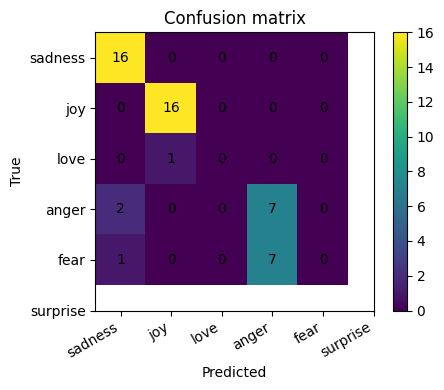

In [78]:

test_output = trainer.predict(tokenized_datasets["test"])
test_logits = test_output.predictions
test_preds = np.argmax(test_logits, axis=-1)
test_true = test_output.label_ids

cm = confusion_matrix(test_true, test_preds)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)

ax.set_xticks(range(len(label_names)))
ax.set_yticks(range(len(label_names)))
ax.set_xticklabels(label_names, rotation=30, ha="right")
ax.set_yticklabels(label_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(f"./artifacts/confusion_matrix.png")
plt.show()


In [82]:
def predict_texts(texts: List[str]) -> pd.DataFrame:
    encoded = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128,
    )
    encoded = {k: v.to(device) for k, v in encoded.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**encoded)
        probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()

    pred_ids = probs.argmax(axis=1)

    true_labels = [id2label[idx] for idx in df["test"]["label"][:len(texts)]]

    rows = []
    for i, (text, pred_id, prob_vector) in enumerate(zip(texts, pred_ids, probs)):
        row = {
            "text": text,
            "true_label": true_labels[i],
            "pred_label": id2label[int(pred_id)],
            "confidence": float(prob_vector[pred_id]),
        }
        for class_id, class_name in id2label.items():
            row[f"prob_{class_name}"] = float(prob_vector[class_id])
        rows.append(row)

    results_df = pd.DataFrame(rows)
    results_df.to_csv('artifacts/sample_predictions.csv', index=False)

    return results_df

new_texts = df["test"]["text"][:5]

predict_texts(new_texts)




,text,true_label,pred_label,confidence,prob_sadness,prob_joy,prob_love,prob_anger,prob_fear,prob_surprise
0,im feeling rather rotten so im not very ambiti...,sadness,sadness,0.486736,0.486736,0.072876,0.113832,0.116699,0.096954,0.112903
1,im updating my blog because i feel shitty,sadness,sadness,0.482756,0.482756,0.065548,0.110937,0.112333,0.105376,0.123051
2,i never make her separate from me because i do...,sadness,sadness,0.350584,0.350584,0.101238,0.127143,0.118762,0.126473,0.175801
3,i left with my bouquet of red and yellow tulip...,joy,joy,0.299488,0.158129,0.299488,0.126849,0.162750,0.122927,0.129857
4,i was feeling a little vain when i did this one,sadness,sadness,0.451149,0.451149,0.066627,0.128349,0.102220,0.098775,0.152880
